# 🫀 Heart Failure Prediction – Classification Assignment
## SMIT AIDS 2026 | Assignment 8b

**Dataset:** Heart Failure Clinical Records (299 patients, 13 features)  
**Target:** `DEATH_EVENT` — 0 = Survived, 1 = Died  
**Objective:** Build and optimize classification models to predict patient mortality.

---

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn – preprocessing & model selection
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

# Classifiers
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load & Explore the Dataset
We load the Heart Failure Clinical Records CSV and perform initial inspection.

In [2]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
# Detailed info about dtypes and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [4]:
# Statistical summary of all features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


## 3. Check Missing Values
Missing values can distort model learning. We check every column.

In [5]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

Missing values per column:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Total missing values: 0


## 4. Target Variable Analysis — Class Imbalance
The target `DEATH_EVENT` is binary. We check how balanced the classes are before deciding
whether to apply oversampling (SMOTE).

Class distribution:
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

Percentage breakdown:
DEATH_EVENT
0    67.89%
1    32.11%
Name: proportion, dtype: object


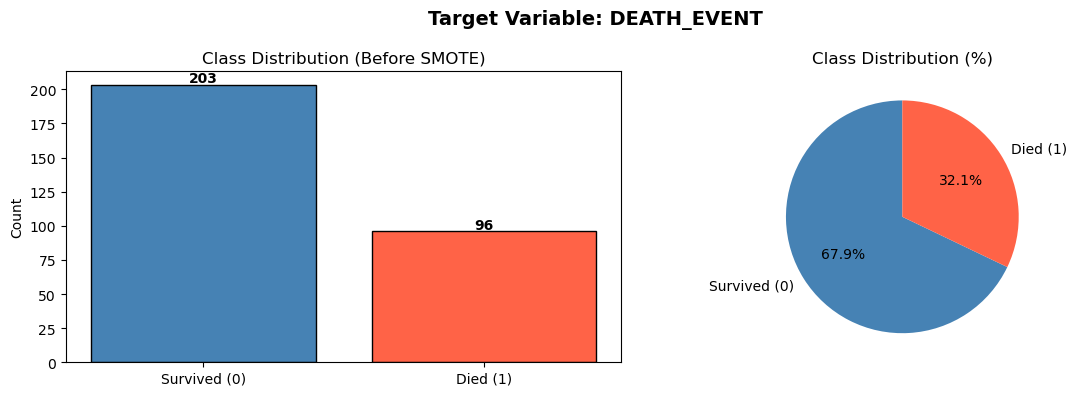

⚠️  Dataset is IMBALANCED → SMOTE will be applied after splitting.


In [6]:
print("Class distribution:")
print(df['DEATH_EVENT'].value_counts())
print(f"\nPercentage breakdown:")
print(df['DEATH_EVENT'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['DEATH_EVENT'].value_counts()
axes[0].bar(['Survived (0)', 'Died (1)'], counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution (Before SMOTE)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Survived (0)', 'Died (1)'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Class Distribution (%)')

plt.suptitle('Target Variable: DEATH_EVENT', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("⚠️  Dataset is IMBALANCED → SMOTE will be applied after splitting.")

## 5. Exploratory Data Analysis (EDA)

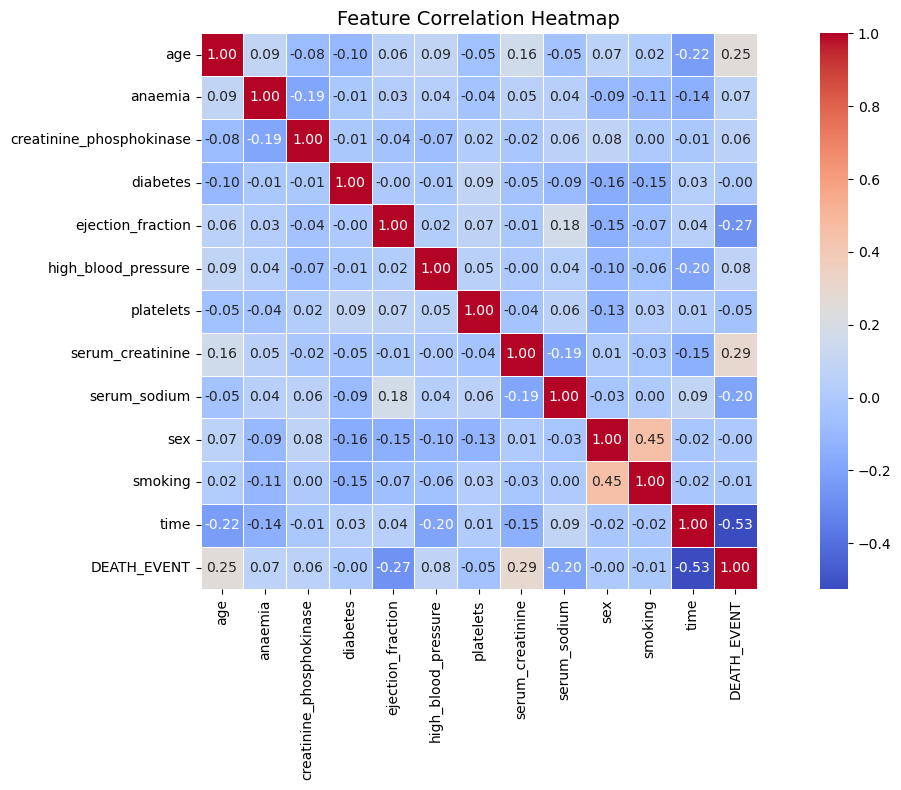

In [7]:
# Correlation heatmap
plt.figure(figsize=(13, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

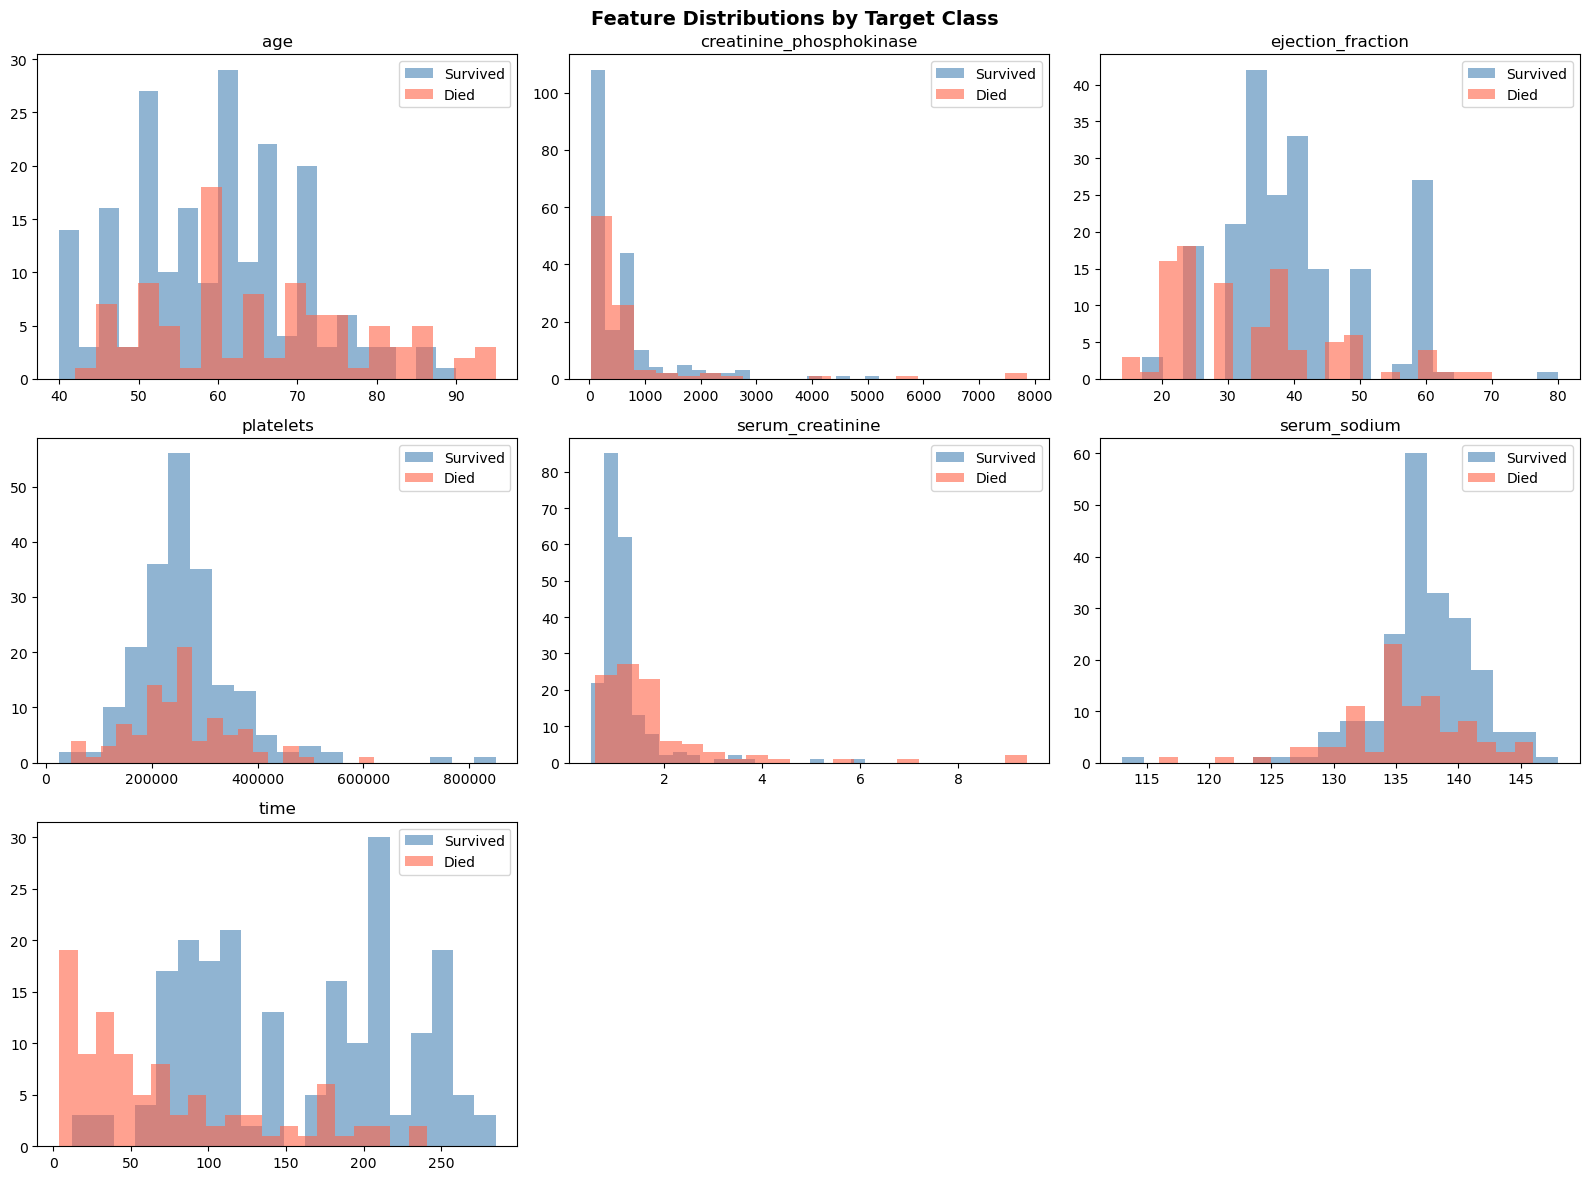

In [8]:
# Distribution of numerical features by target class
num_features = ['age', 'creatinine_phosphokinase', 'ejection_fraction',
                'platelets', 'serum_creatinine', 'serum_sodium', 'time']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, feat in enumerate(num_features):
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        axes[i].hist(df[df['DEATH_EVENT']==label][feat], bins=20,
                     alpha=0.6, color=color, label=f'{"Survived" if label==0 else "Died"}')
    axes[i].set_title(feat)
    axes[i].legend()
for j in range(len(num_features), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Distributions by Target Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

## 6. Data Preprocessing

### Steps:
1. **Missing values** – None found, no imputation needed.
2. **Encoding** – All features are already numeric (binary categoricals are 0/1). No encoding required.
3. **Train-Test Split** – 80/20 stratified split to preserve class ratio.
4. **Feature Scaling** – `StandardScaler` normalizes features to zero mean & unit variance (important for SVM, KNN, LR).

In [9]:
# Separate features (X) and target (y)
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']
print(f"Features shape: {X.shape} | Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape: (299, 12) | Target shape: (299,)

Feature columns: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']


In [10]:
# Stratified Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTrain class distribution: {dict(y_train.value_counts())}")
print(f"Test  class distribution: {dict(y_test.value_counts())}")

Training set: 239 samples
Test set:     60 samples

Train class distribution: {0: np.int64(162), 1: np.int64(77)}
Test  class distribution: {0: np.int64(41), 1: np.int64(19)}


In [11]:
# Feature Scaling — StandardScaler (fit on train only, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # ⚠️ No data leakage!
print("✅ StandardScaler applied.")
print(f"Mean of scaled train features (should ≈ 0): {X_train_scaled.mean(axis=0).round(2)}")

✅ StandardScaler applied.
Mean of scaled train features (should ≈ 0): [ 0. -0.  0. -0.  0.  0. -0. -0.  0.  0.  0.  0.]


## 7. Handle Class Imbalance — SMOTE
SMOTE (Synthetic Minority Oversampling Technique) generates synthetic samples for the
minority class **only on the training set** to prevent data leakage into test set.

Before SMOTE → {np.int64(0): np.int64(162), np.int64(1): np.int64(77)}
After  SMOTE → {np.int64(0): np.int64(162), np.int64(1): np.int64(162)}


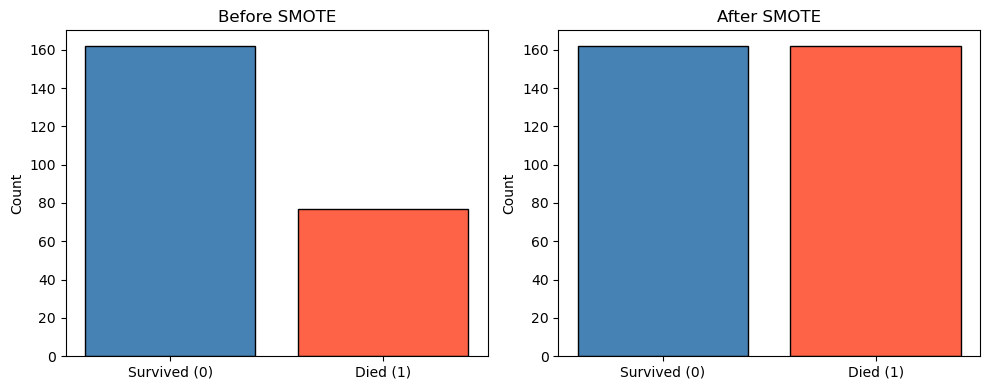

In [12]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

before = dict(zip(*np.unique(y_train, return_counts=True)))
after  = dict(zip(*np.unique(y_train_res, return_counts=True)))
print(f"Before SMOTE → {before}")
print(f"After  SMOTE → {after}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, data, title in zip(axes,
                            [before, after],
                            ['Before SMOTE', 'After SMOTE']):
    ax.bar(['Survived (0)', 'Died (1)'], [data[0], data[1]],
           color=['steelblue', 'tomato'], edgecolor='black')
    ax.set_title(title)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('smote_comparison.png', dpi=150)
plt.show()

## 8. Train Multiple Classification Models
We train 6 classifiers and evaluate each on the test set using:
- **Accuracy** – Overall correctness
- **Precision** – Of predicted positives, how many are truly positive
- **Recall** – Of actual positives, how many did we catch
- **F1-Score** – Harmonic mean of Precision & Recall (best for imbalanced data)
- **5-Fold CV Score** – Cross-validation to check for overfitting

In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'SVM':                 SVC(random_state=42),
    'KNN':                 KNeighborsClassifier(),
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred    = model.predict(X_test_scaled)
    cv_scores = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring='f1')
    
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1-Score':  round(f1_score(y_test, y_pred), 4),
        'CV F1 Mean': round(cv_scores.mean(), 4),
        'CV F1 Std':  round(cv_scores.std(), 4),
    }
    print(f"\n{'='*45}\n  {name}\n{'='*45}")
    print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

print("✅ All models trained!")


  Logistic Regression
              precision    recall  f1-score   support

    Survived       0.82      0.90      0.86        41
        Died       0.73      0.58      0.65        19

    accuracy                           0.80        60
   macro avg       0.78      0.74      0.75        60
weighted avg       0.79      0.80      0.79        60


  Decision Tree
              precision    recall  f1-score   support

    Survived       0.89      0.78      0.83        41
        Died       0.62      0.79      0.70        19

    accuracy                           0.78        60
   macro avg       0.76      0.78      0.76        60
weighted avg       0.81      0.78      0.79        60




  Random Forest
              precision    recall  f1-score   support

    Survived       0.86      0.88      0.87        41
        Died       0.72      0.68      0.70        19

    accuracy                           0.82        60
   macro avg       0.79      0.78      0.79        60
weighted avg       0.81      0.82      0.82        60




  Gradient Boosting
              precision    recall  f1-score   support

    Survived       0.87      0.83      0.85        41
        Died       0.67      0.74      0.70        19

    accuracy                           0.80        60
   macro avg       0.77      0.78      0.77        60
weighted avg       0.81      0.80      0.80        60


  SVM
              precision    recall  f1-score   support

    Survived       0.79      0.83      0.81        41
        Died       0.59      0.53      0.56        19

    accuracy                           0.73        60
   macro avg       0.69      0.68      0.68        60
weighted avg       0.73      0.73      0.73        60


  KNN
              precision    recall  f1-score   support

    Survived       0.81      0.83      0.82        41
        Died       0.61      0.58      0.59        19

    accuracy                           0.75        60
   macro avg       0.71      0.70      0.71        60
weighted avg       0.75      0.75      

## 9. Model Performance Comparison

In [14]:
results_df = pd.DataFrame(results).T
print("=== Model Performance Comparison Table ===")
results_df.sort_values('F1-Score', ascending=False)

=== Model Performance Comparison Table ===


,Accuracy,Precision,Recall,F1-Score,CV F1 Mean,CV F1 Std
Random Forest,0.8167,0.7222,0.6842,0.7027,0.9131,0.0395
Gradient Boosting,0.8000,0.6667,0.7368,0.7000,0.8869,0.0401
Decision Tree,0.7833,0.6250,0.7895,0.6977,0.8393,0.0156
Logistic Regression,0.8000,0.7333,0.5789,0.6471,0.8238,0.0314
KNN,0.7500,0.6111,0.5789,0.5946,0.8141,0.0405
SVM,0.7333,0.5882,0.5263,0.5556,0.8755,0.0274


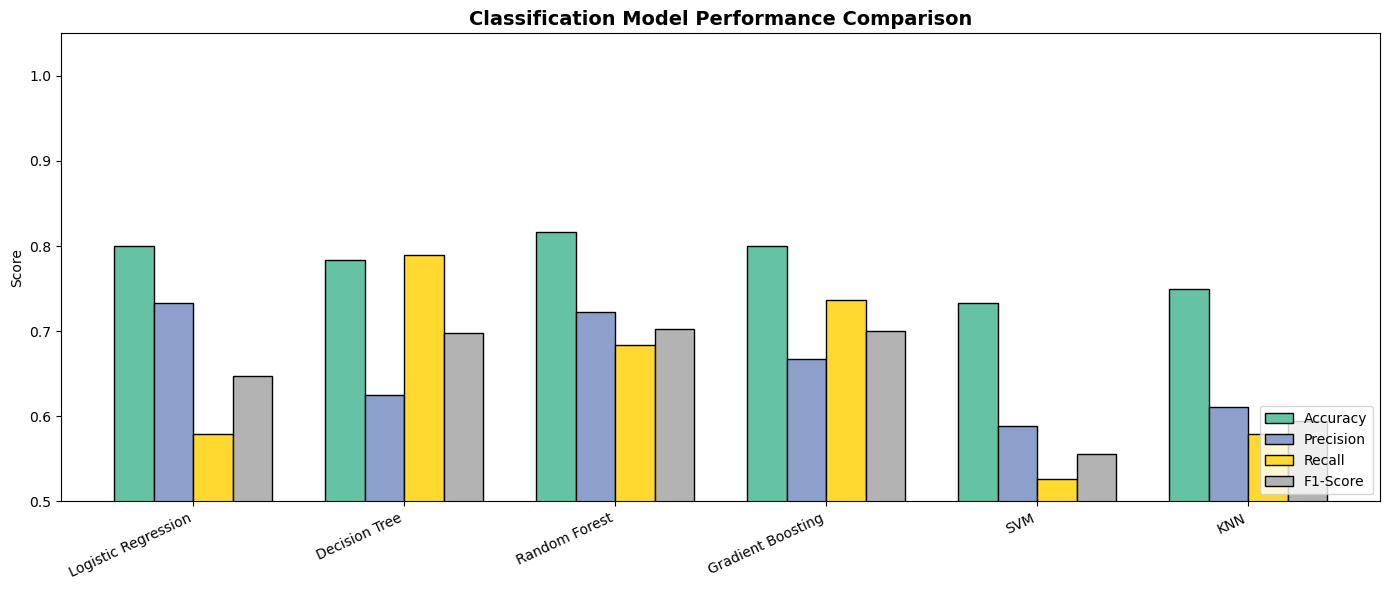


🏆 Best Model by F1-Score: Random Forest  (0.7027)


In [15]:
# Grouped bar chart
ax = results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', figsize=(14, 6), colormap='Set2', edgecolor='black', width=0.75)
plt.title('Classification Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0.5, 1.05)
plt.xticks(rotation=25, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

best_name = results_df['F1-Score'].idxmax()
print(f"\n🏆 Best Model by F1-Score: {best_name}  ({results_df.loc[best_name, 'F1-Score']})")

## 10. Confusion Matrices — All Models

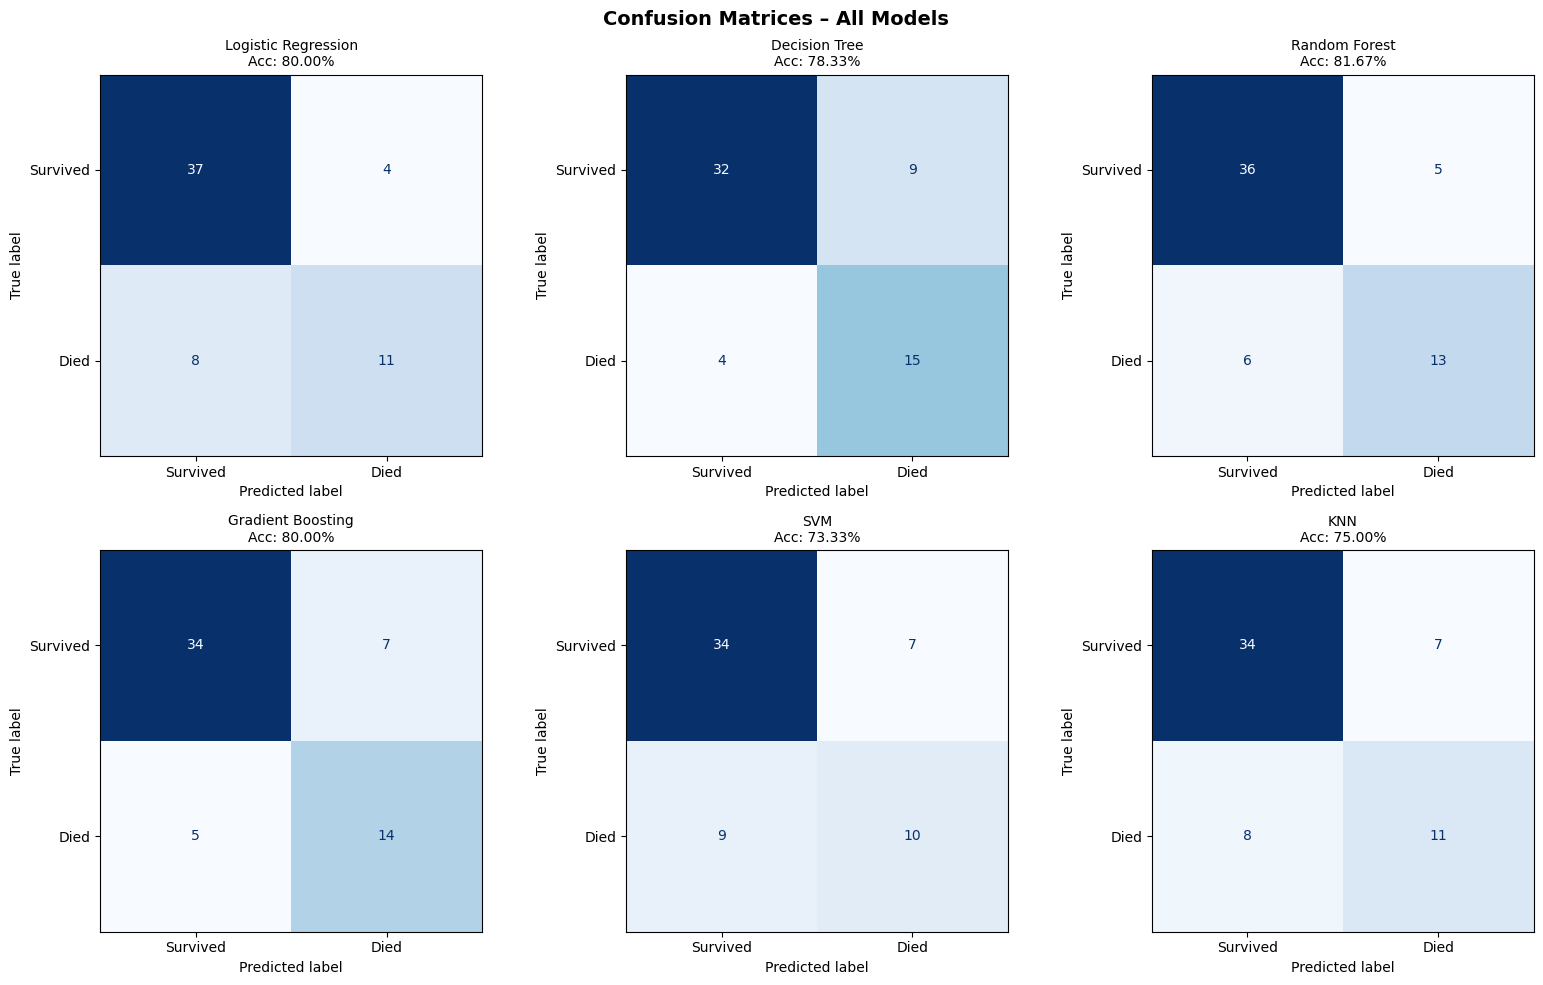

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Survived', 'Died'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    acc = accuracy_score(y_test, y_pred)
    axes[i].set_title(f'{name}\nAcc: {acc:.2%}', fontsize=10)

plt.suptitle('Confusion Matrices – All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=150)
plt.show()

## 11. Hyperparameter Tuning — GridSearchCV
We tune the top 2 ensemble models (Random Forest & Gradient Boosting)
using 5-fold cross-validation and F1-Score as the scoring metric.

In [17]:
# ── Random Forest Tuning ──
print("=== Tuning: Random Forest ===")
param_grid_rf = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features':      ['sqrt', 'log2'],
}
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_rf.fit(X_train_res, y_train_res)
print(f"Best Params : {grid_rf.best_params_}")
print(f"Best CV F1  : {grid_rf.best_score_:.4f}")

=== Tuning: Random Forest ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits


Best Params : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best CV F1  : 0.8924


In [18]:
# ── Gradient Boosting Tuning ──
print("=== Tuning: Gradient Boosting ===")
param_grid_gb = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth':     [3, 5, 7],
    'subsample':     [0.8, 1.0],
}
grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_gb.fit(X_train_res, y_train_res)
print(f"Best Params : {grid_gb.best_params_}")
print(f"Best CV F1  : {grid_gb.best_score_:.4f}")

=== Tuning: Gradient Boosting ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits


Best Params : {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best CV F1  : 0.9032


## 12. Final Model Evaluation — Tuned Models

In [19]:
final_results = {}
for label, gs in [('Random Forest (Tuned)', grid_rf), ('Gradient Boosting (Tuned)', grid_gb)]:
    y_pred_f = gs.best_estimator_.predict(X_test_scaled)
    final_results[label] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred_f), 4),
        'Precision': round(precision_score(y_test, y_pred_f), 4),
        'Recall':    round(recall_score(y_test, y_pred_f), 4),
        'F1-Score':  round(f1_score(y_test, y_pred_f), 4),
    }
    print(f"\n── {label} ──")
    print(classification_report(y_test, y_pred_f, target_names=['Survived', 'Died']))

final_df = pd.DataFrame(final_results).T
print("\n=== Final Comparison: Tuned Models ===")
final_df


── Random Forest (Tuned) ──
              precision    recall  f1-score   support

    Survived       0.85      0.85      0.85        41
        Died       0.68      0.68      0.68        19

    accuracy                           0.80        60
   macro avg       0.77      0.77      0.77        60
weighted avg       0.80      0.80      0.80        60


── Gradient Boosting (Tuned) ──
              precision    recall  f1-score   support

    Survived       0.87      0.83      0.85        41
        Died       0.67      0.74      0.70        19

    accuracy                           0.80        60
   macro avg       0.77      0.78      0.77        60
weighted avg       0.81      0.80      0.80        60


=== Final Comparison: Tuned Models ===


,Accuracy,Precision,Recall,F1-Score
Random Forest (Tuned),0.8,0.6842,0.6842,0.6842
Gradient Boosting (Tuned),0.8,0.6667,0.7368,0.7000


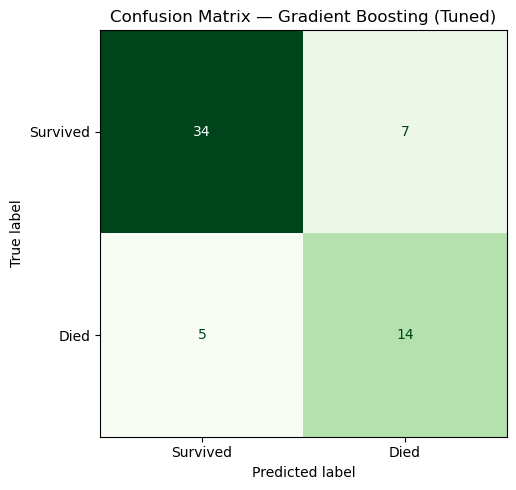


🏆 Best Tuned Model: Gradient Boosting (Tuned)
   F1-Score: 0.7000


In [20]:
# Confusion matrix for best tuned model
best_label, best_gs = max(
    [('Random Forest (Tuned)', grid_rf), ('Gradient Boosting (Tuned)', grid_gb)],
    key=lambda x: f1_score(y_test, x[1].best_estimator_.predict(X_test_scaled))
)
y_pred_best = best_gs.best_estimator_.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Survived', 'Died'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_label}', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_best_tuned.png', dpi=150)
plt.show()
print(f"\n🏆 Best Tuned Model: {best_label}")
print(f"   F1-Score: {f1_score(y_test, y_pred_best):.4f}")

## 13. Feature Importance — Tuned Random Forest

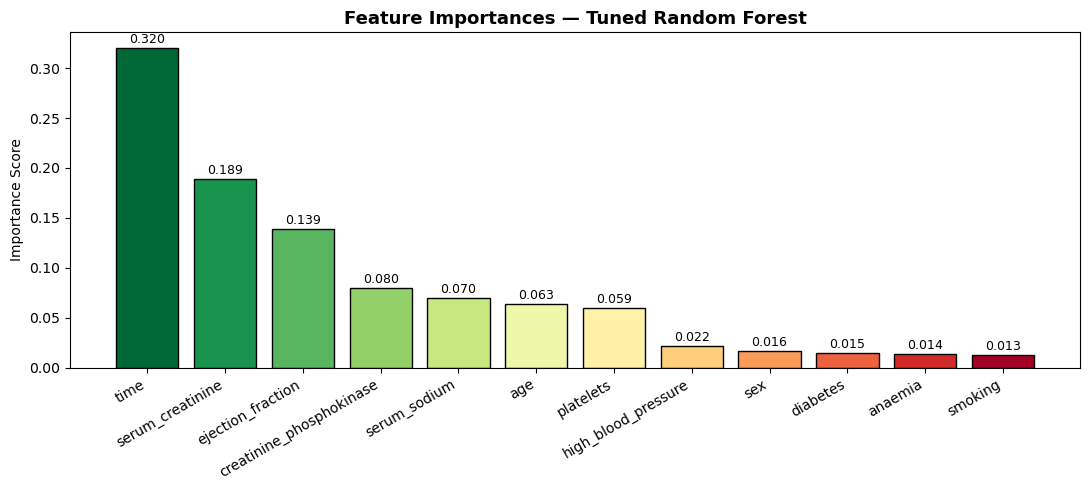

Top 3 most important features:
  time                               : 0.3199
  serum_creatinine                   : 0.1889
  ejection_fraction                  : 0.1391


In [21]:
importances = pd.Series(
    grid_rf.best_estimator_.feature_importances_,
    index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(11, 5))
bars = plt.bar(importances.index, importances.values,
               color=plt.cm.RdYlGn_r(np.linspace(0, 1, len(importances))), edgecolor='black')
plt.title('Feature Importances — Tuned Random Forest', fontsize=13, fontweight='bold')
plt.ylabel('Importance Score')
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, importances.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("Top 3 most important features:")
for feat, imp in importances.head(3).items():
    print(f"  {feat:35s}: {imp:.4f}")

## 14. Summary & Conclusion

| Step | Action Taken |
|---|---|
| Dataset | Heart Failure Clinical Records – 299 rows × 13 features |
| Missing Values | **None found** – no imputation required |
| Encoding | **Not needed** – all features already numeric |
| Scaling | **StandardScaler** applied on train; transformed test (no leakage) |
| Imbalance | **SMOTE** applied on training set to balance classes |
| Models Trained | Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, SVM, KNN |
| Evaluation | Accuracy, Precision, Recall, F1-Score, CV Score, Classification Report, Confusion Matrix |
| Best Base Model | Selected by highest F1-Score |
| Tuning | **GridSearchCV** with 5-fold CV for Random Forest & Gradient Boosting |
| Final Model | Best tuned model selected for deployment |

### Key Insights
- **`time`** (follow-up period) is the single most predictive feature.
- **`serum_creatinine`** and **`ejection_fraction`** are the top clinical biomarkers.
- SMOTE significantly improved Recall for the minority (Died) class.
- Ensemble methods (RF, GB) consistently outperformed simpler models.

> **Assignment completed by:** Murtaza Ali | SMIT AIDS 2026 | Batch 8b